В случае свободных фермионов на квадратной решётке гамильтониан имеет вид:
$$\hat H = -t\sum_{\langle ij \rangle \sigma}(c^{\dagger}_{i\sigma}c_{j\sigma} + h.c.) -\mu \sum_{i\sigma}n_{i\sigma},$$
где $t$ - величина хоппинга, $\mu$ - химический потенциал, $c^{(\dagger)}_{i\sigma}$ - оператор уничтожения (рождения) фермиона на узле $i$ со спином $\sigma$, $n_{i\sigma}=c^{\dagger}_{i\sigma}c_{i\sigma}$ - оператор плотности фермионов. Поскольку в системе нет беспорядка, то система является *трансляционно-инвариантной* в случае периодических граничных условий. Это значит, что наша квадратная решётка скручена в тор. В таком случае движение электронов описывается плоскими волнами $e^{i\vec{k}\vec{r}_i}$, где $\vec{r}_i$ - это вектор положения электрона в решётке.

Значит, можем использовать преобразование Фурье для оператора рождения $c^{(\dagger)}_{i\sigma} = \frac{1}{\sqrt{N}}\sum_{\vec{k}}c^{(\dagger)}_{\vec{k}\sigma}e^{i\vec{k}\vec{r}_i}$, где $\vec{k} \in [-\pi,\pi)\times[-\pi, \pi)$. Если подставить это выражение прямо в гамильтониан, то получим:
$$\hat{H} = \sum_{\vec{k}\sigma}(\varepsilon(\vec{k}) - \mu)c^{\dagger}_{\vec{k}\sigma}c_{\vec{k}\sigma},$$
где закон дисперсии даётся выражением:
$$\varepsilon(\vec{k}) = -2t(\cos{k_x} + \cos{k_y}).$$
Видно, что теперь матрица Гамильтониана диагональна в импульсном пространстве (поскольку всего один индекс). Ниже мы посмотрим на график для дисперсии и на поверхность Ферми, которая получается при разных значениях химического потенциала.

In [1]:
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
from ed_solver import EDSolverCore
import ana_cont.continuation as cont

ModuleNotFoundError: No module named 'ed_solver._ed_solver'

In [2]:
def compute_energy_for_square_lattice(size_x, size_y, hopping):
    """
    This function calculate energy dispersion for square lattice with nearest-neighbor hoppings.
    Return - 2d-array of floats.
    """
    kx, ky = (
        np.linspace(-np.pi, np.pi, size_x, endpoint=False),
        np.linspace(-np.pi, np.pi, size_y, endpoint=False)
    )

    kx_mesh, ky_mesh = np.meshgrid(
        kx, ky, indexing='ij'
    )

    xi_k = -2 * hopping * (
        np.cos(kx_mesh) + np.cos(ky_mesh)
    )

    return xi_k.flatten()

In [3]:
def plot_energy_map(size_x, size_y, hopping):
    """
    This function plot energy dispersion for given chemical potential.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    kx, ky = (
        np.linspace(-np.pi, np.pi, size_x, endpoint=False),
        np.linspace(-np.pi, np.pi, size_y, endpoint=False)
    )

    kx_mesh, ky_mesh = np.meshgrid(
        kx, ky, indexing='ij'
    )

    xi_k = -2 * hopping * (
        np.cos(kx_mesh) + np.cos(ky_mesh)
    )

    levels = np.linspace(xi_k.min(), xi_k.max(), 15)

    pcm = ax.pcolormesh(
        kx_mesh, ky_mesh, xi_k,
        shading='auto',
        cmap='RdBu_r'
    )

    cs = ax.contour(
        kx_mesh, ky_mesh, xi_k,
        levels=levels,
        colors='black',
        linewidths=0.7
        )

    ax.clabel(cs, inline=True, fontsize=9, fmt='%.1f')
    
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r'$\xi_{\mathbf{k}}$', fontsize=30)
    
    ax.set_xlabel(r'$k_x$', fontsize=30)
    ax.set_ylabel(r'$k_y$', fontsize=30)
    ax.set_title(r'Energy dispersion $\xi_{\mathbf{k}}$', fontsize=30)

    ax.tick_params(axis='both', labelsize=20)
    cbar.ax.tick_params(labelsize=20)

    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

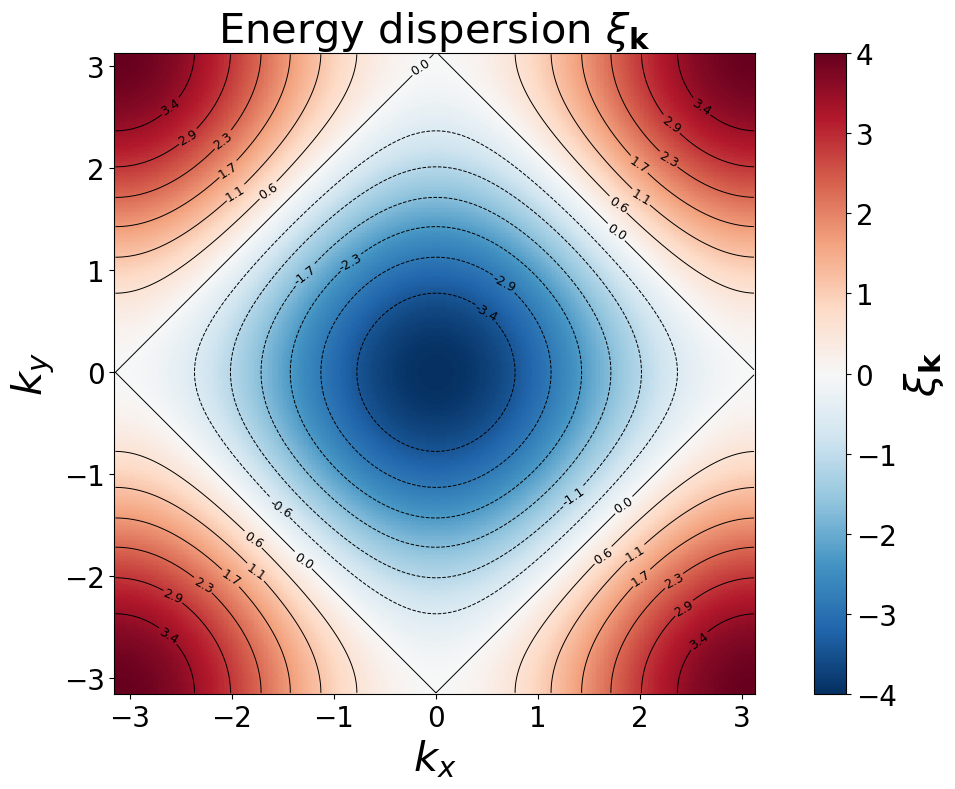

In [4]:
size_x, size_y = 256, 256
hopping = 1.0

plot_energy_map(
    size_x, size_y, hopping
)

На лекции Вы познакомились с понятием функции Грина $G(\vec{r}, t;\vec{r}', t')$, которая представляет собой отлик системы на добавление частицы в момент времени $t$ в точке $\vec{r}$ и удалении этой частицы в момент $t'$ в $\vec{r}'$. Поскольку мы изучаем физику равновесную, то наша функция Грина зависит только от разности времён, то есть $G(t-t';\vec{r}, \vec{r}')$. Появление же разности времён, позволяет нам использовать преобразование Фурье и перейти в частотное представление $G(\omega; \vec{r}, \vec{r}')$. Это важный факт, поскольку все свёртки по времени, которые возникают при расчёте различных поправок от взаимодействия, превращаются в произведения Фурье-образов. 

В общем виде, функция Грина записывается в виде $G(\omega) = \bra{i}(\omega - \hat H)^{-1}\ket{j}$, где $\ket{j}$ - это состояние электрона, находящегося на узле $j$. И обычно физический интерес величина, которая определяется мнимой частю функции Грина, а именно *плотность состояний* $\rho(\omega) = -\frac{1}{\pi}\Im{G^R(\omega)}$, где $R$ - означает запаздывающую функцию Грина. Именно её можно померить разными способами: например, с помощью туннельной микроскопии или ARPES (angle-resolved photoemission spectroscopy).

Но для того, чтобы освоиться с этим понятием, мы рассмотрим простейший гамильтониан вида
$$\hat H = \varepsilon c^{\dagger}c,$$
где $\varepsilon$ - один единственный уровень энергии. В таком случае, выражение для функции Грина
$$G^R(\omega) = \lim_{\delta\to 0+}\frac{1}{\omega - \epsilon + i\delta},$$
где $\delta$ - бесконечно малая константа.

In [5]:
def make_local_one_energy_GF(frequency, energy, delta):
    """
    This function calculate retarded Greens function, i.e. omega + 1j*delta in denominator.
    """
    return 1 / (frequency - energy + 1j * delta)

In [6]:
def plot_DOS_for_one_level(freq_min, freq_max, freq_num:int, energy, delta):
    """
    This function plot density of states for a system with one energy level.
    :param freq_min: minimal frequency;
    :param freq_max: maximal frequency;
    :param freq_num: number of frequencies;
    """
    frequencies = np.linspace(freq_min, freq_max, freq_num)

    GF = make_local_one_energy_GF(
        frequencies, energy, delta
    )

    DOS = -(1/np.pi) * GF.imag

    plt.figure(figsize=(12, 8))
    plt.plot(frequencies, DOS, color='#120CB6', linewidth=2.0)
    plt.axvline(x=energy, label=f'Energy={energy}', color='red', linewidth=1.5)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(r'Frequency, $\omega$', fontsize=30)
    plt.ylabel(r'$\text{DOS}$', fontsize=30)
    plt.xlim(-5.0, 5.0)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

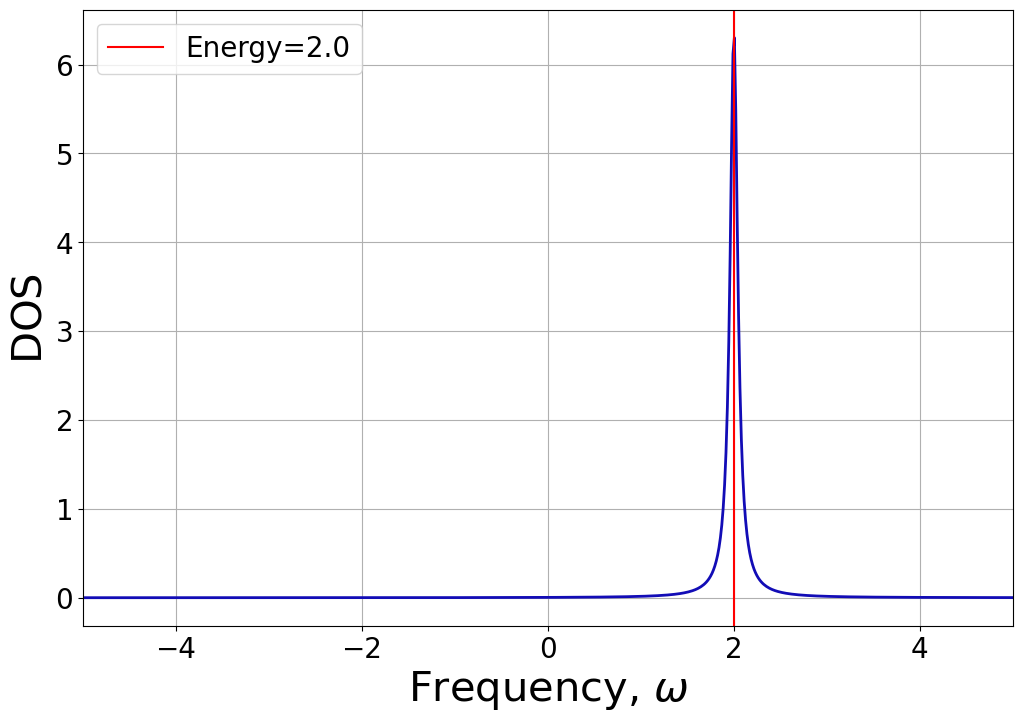

In [7]:
plot_DOS_for_one_level(-6.0, 6.0, 800, 2.0, 5e-2)

Другим простым, но уже не таким тривиальным пределом является **атомный предел**, который получается из модели Хаббарда в случае, если $t=0$. То есть гамильтониан имеет вид:
$$\hat{H} = -\mu\sum_{i\sigma}n_{i\sigma} + U\sum_{i}n_{i\uparrow}n_{i\downarrow},$$
где $U$ - величина взаимодействия. На лекции было показано, что функция Грина в таком случае:
$$G^R_{\sigma}(\omega) = \lim_{\delta \to 0+}\frac{1 - \langle n_{\sigma}\rangle}{\omega + \mu + i\delta} + \frac{\langle n_{\sigma}\rangle}{\omega + \mu - U + i\delta},$$
которое для случая полузаполнения $\langle n_{\sigma}\rangle = 0.5,\ \mu = U/2$ превращается в 
$$G^R_{\sigma}(\omega) = \lim_{\delta \to 0+}\frac{0.5}{\omega + U/2 + i\delta} + \frac{0.5}{\omega - U/2 + i\delta}.$$

**Задача**:
Напишите сначала функцию, которая считает функцию Грина в атомном пределе.

In [8]:
def compute_atomic_limit_GF():
    """
    This function calculate Greens function in the atomic limit.
    
    """
    

    return 

Теперь, чтобы убедиться, что Вы всё верно перенесли, *построим плотность состояний для функции Грина в атомном пределе*. Мы ожидаем, что должно быть два пика, которые расположены на $-U/2$ и на $U/2$, что описывает процессы перехода $\ket{0} \leftrightarrow \ket{\sigma}$ и $\ket{\sigma} \leftrightarrow \ket{\uparrow \downarrow}$, соотвественно.

In [9]:
def plot_DOS_atomic_limit(freq_min, freq_max, freq_num:int, ):
    """
    This function plot density of states for atomic limit Greens function.
    """
    frequencies = np.linspace(freq_min, freq_max, freq_num)

    GF = compute_atomic_limit_GF(
        
    )

    DOS = 
    DOS /= np.trapezoid(DOS, frequencies)

    plt.figure(figsize=(12, 8))
    plt.plot(frequencies, DOS, color='#120CB6', linewidth=2.0)
    plt.axvline(x=-chemical, label=f'Energy={-chemical}', color='red', linewidth=1.5)
    plt.axvline(x=interaction-chemical, label=f'Energy={interaction-chemical}', color='red', linewidth=1.5)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(r'Frequency, $\omega$', fontsize=30)
    plt.ylabel(r'$\text{DOS}$', fontsize=30)
    plt.xlim(-5.0, 5.0)
    plt.grid()
    plt.legend(fontsize=20)
    plt.show()
    
    

SyntaxError: invalid syntax (1351668295.py, line 11)

In [10]:
# Plot density of states for half-filling case
interaction = 2.0
plot_DOS_atomic_limit(-6.0, 6.0, 800, 0.5, interaction / 2, interaction, 5e-2)

NameError: name 'plot_DOS_atomic_limit' is not defined

Наконец, мы в состоянии сделать плотность состояний для свободных фермионов на квадратной решётке. Выше, мы обсуждали вид дисперсии для этого случая и написали аналитическое выражение для него:
$$\varepsilon(\vec{k}) = -2t(\cos{k_x} + \cos{k_y}),$$
где $k_x$ и $k_y$ живут в первой зоне Бриллюэна. Теперь, поскольку гамильтониан в импульсном пространстве диагонален, то функция Грина в таком случае будет иметь вид:
$$G^R_{\vec{k}\sigma}(\omega) = \lim_{\delta \to 0+}\frac{1}{\omega -\varepsilon(\vec{k}) + \mu + i\delta}.$$

Поскольку уровней энергии стало много, то нам нужен объект, который собирает их все вместе. Но это делает именно *локальная функция Грина*:
$$G^R(\omega) = \frac{1}{N}\sum_{\vec{k}}G^R_{\vec{k}}(\omega).$$

**Задача**:
Напишите функцию, которая считает локальную функцию Грина для квадратной решётки. 

In [11]:
def make_local_GF():
    """
    This function make local retarted Greens function in clean case for square lattice.
    

    Return - local Greens function as 1d-array with shape(freq_num);
    """
    

    return 

Для того, чтобы проверить правильность расчёта локальной функции Грина, нам необходимо также, как и в случае атомного предела увидеть плотность состояний. Поэтому следующая

**Задача**:
Написать функцию, которая строит плотность состояний.

In [12]:
def plot_DOS_for_free_square_lattice(freq_min, freq_max, freq_num:int, size_x, size_y, hopping, delta):
    """
    This function plot density of states for free fermions on the square lattice with nearest-neighbor hopping.
    """
    frequencies = np.linspace(freq_min, freq_max, freq_num)
    
    
    GF_loc =

    DOS = 
    DOS /= np.trapezoid(DOS, frequencies)

    plt.figure(figsize=(12, 8))
    plt.plot(frequencies, DOS, color='#120CB6', linewidth=2.0)
    plt.axvline(x=chemical, label='Van Hove', color='red', linewidth=1.5)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(r'Frequency, $\omega$', fontsize=30)
    plt.ylabel(r'$\text{DOS}$', fontsize=30)
    plt.xlim(-5.0, 5.0)
    plt.grid()
    plt.legend(fontsize=20)
    plt.show()

SyntaxError: invalid syntax (2888211982.py, line 8)

In [13]:
# Here we plot density of states for free fermions on the square lattice
plot_DOS_for_free_square_lattice(-6.0, 6.0, 800, 64, 64, 1.0, 5e-2)

NameError: name 'plot_DOS_for_free_square_lattice' is not defined

Теперь, убедившись в том, что мы правильно считаем локальную функцию Грина, мы можем перейти непосредственно к написанию $\text{DMFT}$-кода. Идея динамической теории среднего поля ($\text{DMFT}$) заключается в том, что мы рассматриваем один узел решётки, который описывается гамильтонианом атомного предела, в некотором эффективном окружении, с которым этот атом умеет обмениваться электронами. Это называется *примесной задачей Андерсона* и гамильтониан такой задачи:
$$\hat H = U\left(n_{\uparrow} - \frac{1}{2}\right)\left(n_{\downarrow} - \frac{1}{2}\right) -\mu \sum_{i\sigma}n_{i\sigma} + \sum_{l\sigma}t_{l\sigma}(c^{\dagger}_{\sigma}d_{l\sigma} + h.c.) + \varepsilon_{l\sigma} d^{\dagger}_{l\sigma}d_{l\sigma},$$
где $c^{(\dagger)}$ - оператор уничтожения (рождения) электрона на атоме, а $d^{(\dagger)}_{l\sigma}$ - оператор рождения (уничтожения) на уровне энергии окружения, которое называется ещё *баней*, $t_{l\sigma}$ - величина прыжка в баню, $\varepsilon_{l\sigma}$ - энергия уровня бани. $\mu$ - химический потенциал, который теперь измеряется от $U/2$, то есть теперь полузаполнение соотвествует $\mu =0$, а не $\mu = U/2$ как это было в случае атомного предела.

Эту же задачу можно мыслить так: имеется атом, который может обмениваться электронами с баней, в некотором эффективном внешнем *гибридизующем поле* $\Delta(i\omega_n)$. То есть вместо того, чтобы думать о точных характеристиках окружения (его уровнях $\varepsilon_{l\sigma}$) и прыжках на эти уровни ($t_{l\sigma}$), можно думать об этом поле, которое имеет вид:
$$\Delta_{\sigma}(i\omega) = \sum_{l}\frac{t^2_{l\sigma}}{i\omega_n - \varepsilon_{l\sigma}}.$$

Это выражение можно понять следующим образом: $\frac{1}{i\omega_n - \varepsilon_{l\sigma}}$ - похоже на функцию Грина для электрона в бане - то есть описывает отклик бани на попадание в неё электрона и вытаскивание его через какое-то время. Множитель $t^2_l$ определяет "вероятность" прыжка электрона с атома в баню и обратно на атом. Этот множитель появляется естественным образом, поскольку электроны попадают в баню с атома и могут вернуться на него.

В результате, мы можем написать функцию Грина примесной задачи, используя гибридизацию:
$$G^{-1}_{\sigma\text{imp}}(i\omega_n) = i\omega_n + \mu - \Sigma_{\sigma\text{imp}}(i\omega_n) - \Delta_{\sigma}(i\omega_n),$$
где $\Sigma_{\sigma \text{imp}}$ - это поправки к функции Грина примесной задачи, приходящие из-за наличия взаимодействия $U$.

Теперь поговорим о том, что делает солвер, который решает примесную задачу Андерсона. Происходит следующее:
1. Подаётся какая-то гибридизация $\Delta_{\sigma}(i\omega_n)$;
2. С помощью нелинейной оптимизации параметры бани $t_{l\sigma}, \varepsilon_{l\sigma}$ подбираются так, чтобы гибридизация из формулы выше маскимально совпадала с данной гибридизацией;
3. С найденными параметрами бани решается примесная задача Андерсона;
4. Найденные собственные вектора и собственные значения используются для нахождения функции Грина $G_{\sigma\text{imp}}(i\omega_n)$ с помощью *представления Леманна* (могут быть также найдены другие наблюдаемые, которые прописаны в документации);
5. Вычисляется также $\Sigma_{\sigma \text{imp}}$ с помощью формулы выше, где используется уже гибридизация, полученная из нелинейной оптимизации;

Ниже написана функция, которая делает хорошее начальное приближение для гибридизации $\Delta(i\omega_n)$, что ускоряет сходимость $\text{DMFT}$-петли.

In [14]:
def make_init_hybridization(beta, freq_number):
    """
    This function make initial guess of hybridization function from free case.
    :param beta: float inverse temperature;
    :param freq_number: number of Matsubara frequencies;

    Return - 1d-array with shape (freq_number, );
    """
    Matsubara_freq = 1j * np.pi * (2 * np.arange(0, freq_number) + 1) / beta

    Delta = -4j * np.sqrt(np.abs(Matsubara_freq) ** 2 + 1) ** (-1)

    return Delta

Теперь, поскольку у нас есть возможность получить $\Sigma_{\sigma \text{imp}}$, то локальная функция Грина будет находится аналогично свободному случаю, только теперь:
$$G_{\sigma}(i\omega_n) = \frac{1}{N}\sum_{\vec{k}\in\text{BZ}}\frac{1}{i\omega_n - \varepsilon_{\vec{k}} - \Sigma_{\sigma\text{imp}}}.$$
Заметьте, что здесь нет $\mu$, поскольку оно уже зашито в $\Sigma_{\sigma\text{imp}}$. 

Однако, при использовании формулы выше для расчёта локальной функции Грина могут возникнуть трудности. Если подставлять $\Sigma_{\sigma \text{imp}}$, то сначала ошибка в процессе самосогласования будет уменьшаться, а потом начнёт расти и программа прекратит расчёт. Проблема возникает из-за того, что в $\Sigma_{\sigma \text{imp}}$ имеется два объекта $G_{\text{imp}}$ и $\Delta_{\sigma}(i\omega_n)$, каждый из которых содержит текущее приближение $t_{l\sigma}, \varepsilon_{l\sigma}$. Поэтому лучше искать локальную функцию Грина в другом виде. Для этого подставим выражение $\Sigma_{\sigma\text{imp}}$:
$$G_{\sigma}(i\omega_n)= \frac{1}{N}\sum_{\vec{k}\in\text{BZ}}\frac{1}{\Delta^{(0)}_{\sigma}(i\omega_n) + G^{-1}_{\text{imp}}(i\omega_n) - \varepsilon_{\vec{k}}},$$
где $\Delta^{(0)}_{\sigma}(i\omega_n)$ - это гибридизация, которая была подана солверу, а $G_{\text{imp}}$ - функция Грина, полученная уже после нахождения параметров бани и точной диагонализации.

**Задача**: напишите функцию, которая считает локальную функцию Грина через примесную функцию Грина и гибридизацию для обоих спинов.

In [15]:
def compute_local_GF(G_imp_up, G_imp_down, hybr_up, hybr_down):
    """

    :param G_imp_up (G_imp_down): 1d-array of impurity GF with shape (Nw, );
    :param hybr_up (hybr_down): 1d-array of the hybridization function with shape (Nw, );

    Return: GF_loc - 2d-array of local Greens function with shape (2, Nw) where 2 is dimension of spin;
    """

    return 

Теперь, сделаем ещё один шаг вперёд и просто проверим, что солвер работает как ожидается. Для этого, необходимо сделать следующее:
1. Инициализировать класс солвера solver=EDSolverCore(Beta=, Nbath_max=, Nw=), где Beta - обратная температура $\beta = 1/T$, $N_{\text{bath}}$ - количество уровней в бане, $N_{\omega}$ - количество Мацубаровских частот (лучше подавать около 150 и больше);
2. Инициализировать Мацубаровские частоты, начальную гибридизацию и всё, что нужно для расчёта локальной функции Грина;
3. Решить инициализированную проблему с помощью точной диагонализации, используя функция класса solver.solve(U=, Delta_up=, Delta_down=, N_bath=, h_loc=0.0, mu_loc=0.0). Это связано с тем, что мы работаем при полузаполнении и никакого магнитного поля нет. После это шага нам доступна примесная функция Грина $G_{\sigma \text{imp}}$, которую можно извлечь из солвера командой solver.G_up или solver.G_down (вернёт одномерный массив длиной $N_{\omega}$);
5. Посчитать локальную функцию Грина, используя полученную примесную функцию Грина и гибридизацию. 
6. Вывести на экран разницу между примесной и локальной функцией Грина на разных частотах $|G_{\sigma \text{imp}} - G_{\sigma}(i\omega_n)|$;
7. Вывести на экран также сортированные параметры бани $t_{l\sigma}, \varepsilon_{l\sigma}$, которые были получены после решения примесной задачи. Они извлекаются командами solver.t2u, solver.t2d, solver.eu, solver.ed;

In [16]:
def dmft_step(size_x:int, size_y:int, hopping:float, Delta_init_up, Delta_init_down, chemical, beta, bath_number, freq_number, 
                   interaction, h_mag, max_iter, atol, rtol, mix):
    """
    This function make only one step in DMFT loop. We need it for check of library work.
    """
    # 1. Initialize solver class
    
    
    # 2. Initialize Matsubara and energies
    
    
    fig, (ax_error, ax_bath_en, ax_bath_t) = plt.subplots(1, 3)

    # 3. Solve impurity problem

    
    # 4. Extract impurity GF and calculate local GF
    

    # 5. Compute |G_imp - G_loc|

    ax_error.clear()
    ax_error.plot(Matsubara_freq.imag, G_up_error, marker="o", linestyle='--', label=r'$G_{\uparrow}$', markersize=5, linewidth=2.0, color='#0501DA')
    ax_error.plot(Matsubara_freq.imag, G_down_error, marker="s", linestyle='--', label=r'$G_{\downarrow}$', markersize=5, linewidth=2.0, color="#1AAD26")
    ax_error.set_xlabel(r"$\omega_n$", fontsize=20)
    ax_error.set_ylabel(r"$|G_{\text{imp}} - G_{\text{loc}}|$", fontsize=20)
    ax_error.grid(True)

    ax_error.relim()
    ax_error.autoscale_view()
    ax_error.legend(loc='upper right', fontsize=20)

    ax_error.set_title(
        f"Iteration {1}, "
        f"max error = {max(max(G_up_error), max(G_down_error)):.3e}"
    )
    # 6. Bath parameters
    ax_bath_en.clear()
    ax_bath_en.plot(range(bath_number), here_eu, marker="o", linestyle='--', label=r"$\epsilon_\uparrow$", markersize=7, linewidth=2.0, color='#0501DA')
    ax_bath_en.plot(range(bath_number), here_ed, marker="s", linestyle='--', label=r"$\epsilon_\downarrow$", markersize=7, linewidth=2.0, color="#1AAD26")
    ax_bath_en.legend(loc='upper right', fontsize=20)
    ax_bath_en.set_xlabel(r"Bath index, $N$", fontsize=20)
    ax_bath_en.set_ylabel(r"Bath parameters, $\epsilon_l$", fontsize=20)
    ax_bath_en.grid(True)

    ax_bath_t.clear()
    ax_bath_t.plot(range(bath_number), here_t2u, marker="o", linestyle='--', label=r"$t_{2\uparrow}$", markersize=7, linewidth=2.0, color='#0501DA')
    ax_bath_t.plot(range(bath_number), here_t2d, marker="s", linestyle='--', label=r"$t_{2\downarrow}$", markersize=7, linewidth=2.0, color="#1AAD26")
    ax_bath_t.legend(loc='upper right', fontsize=20)
    ax_bath_t.set_xlabel(r"Bath index, $N$", fontsize=20)
    ax_bath_t.set_ylabel(r"Bath parameters, $t_l$", fontsize=20)
    ax_bath_t.grid(True)


    fig.tight_layout()
    fig.canvas.draw()
    fig.canvas.flush_events()

    plt.show()

    return solver

NameError: name 'Matsubara_freq' is not defined

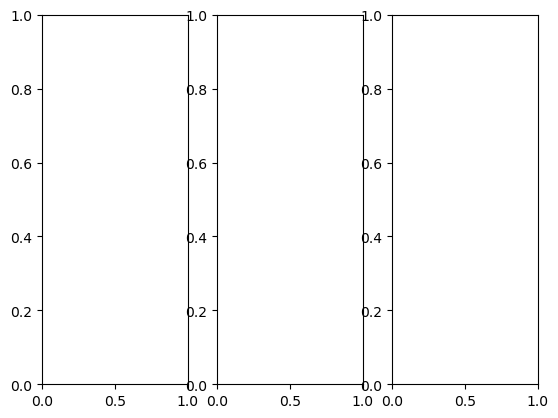

In [17]:
size_x, size_y = 8, 8
hopping, chemical, interaction = 1.0, 0.0, 2.0
beta, freq_number = 5.0, 150

init_guess_up = make_init_hybridization(beta, freq_number)
init_guess_down = init_guess_up.copy()

dmft_step(
    size_x, size_y, hopping, init_guess_up, init_guess_down, chemical, beta, 
    4, freq_number, interaction, 0.0, 100, 1e-5, 1e-3, 0.3
)

Теперь, когда мы разобрались в том, как устроен один шаг $\text{DMFT}$ мы можем написать самую главную функцию в этом блокноте - функцию, которая реализует $\text{DMFT}$-петлю. **Алгоритм** должен быть следующий:
1. Инициализировать класс солвера solver=EDSolverCore(Beta=, Nbath_max=, Nw=), где Beta - обратная температура $\beta = 1/T$, $N_{\text{bath}}$ - количество уровней в бане, $N_{\omega}$ - количество Мацубаровских частот (лучше подавать около 150 и больше);
2. Инициализировать Мацубаровские частоты, начальную гибридизацию и всё, что нужно для расчёта локальной функции Грина, а также массивы ошибок G_error_up, G_error_down, который будет обновляться на каждой итерации и выводится на экран;
3. В цикле нужно:
   1. Решить инициализированную проблему с помощью точной диагонализации, используя функция класса solver.solve(U=, Delta_up=, Delta_down=, N_bath=, h_loc=0.0, mu_loc=0.0);
   2. Посчитать локальную функцию Грина, используя полученную примесную функцию Грина и гибридизацию. Посчитать разницу локальной функции Грина и примесной на разных частотах $|G_{\sigma \text{imp}} - G_{\sigma}(i\omega_n)|$;
   3. Если условие самосогласования не выполнено c заданной точностью atol, rtol, то есть $G_{\sigma\text{imp}}(i\omega_n)\ne G_{\sigma}(i\omega_n)$, то обновляем гибридизацию $\Delta_{\sigma}(i\omega_n)+=\alpha(G^{-1}_{\sigma\text{imp}}(i\omega_n) - G^{-1}_{\sigma}(i\omega_n))$, где $\alpha$ - это коэффициент смешивания (обычно берётся $0.2-0.3$). Если условие выполнено, то прерываем цикл;

In [18]:
def dmft_loop(size_x:int, size_y:int, hopping:float, Delta_init_up, Delta_init_down, chemical, beta, bath_number, freq_number, 
                   interaction, h_mag, max_iter, atol, rtol, mix):
    
    """
    This function make self-consistent DMFT-loop on base of solver from EdSolverCore;

    :param size_x, size_y: integer sizes of lattice;
    :param hopping: float parameter of hopping;
    :param Delta_up (Delta_down): 1d-array of initial guess of hybridization with shape (freq_number, );
    :param chemical: THE VALUE IS MEASURED FROM HALF-FILLING, I.E. MU=0 IS MU=U/2 IN USUAL UNITS;
    :param beta: float inverse temperature;
    :param bath_number: maximal number of bath levels;
    :param freq_number: number of Matsubara frequencies;
    :param interaction: value of interaction U;
    :param h_mag: value of external Zeeman magnetic field;
    :param max_iter: number of possible iterations;
    :param atol: value of absolute tolerance;
    :param rtol: value of relative tolerance;
    :param mix: value of iteration mixing;
    """

    # 1. Initialize solver class
    

    # 2. Initialize Matsubara, hybridization, array of errors
    
    
    converged = False
    bar = tqdm(range(max_iter), 
        desc=f"Performing DMFT for T = {beta ** (-1):.4f}, U = {interaction:.4f} ...",
        leave=False)




    
    plt.ion()

    fig, (ax_error, ax_bath_en, ax_bath_t) = plt.subplots(1, 3)

    for idx in bar:

        # 3.A. Solve impurity problem
        

        # 3.B. Extract impurity GF and calculate local GF
        

        ax_error.clear()
        ax_error.plot(Matsubara_freq.imag, G_up_error, marker="o", linestyle='--', label=r'$G_{\uparrow}$', markersize=5, linewidth=2.0, color='#0501DA')
        ax_error.plot(Matsubara_freq.imag, G_down_error, marker="s", linestyle='--', label=r'$G_{\downarrow}$', markersize=5, linewidth=2.0, color="#1AAD26")
        ax_error.set_xlabel(r"$\omega_n$", fontsize=20)
        ax_error.set_ylabel(r"$|G_{\text{imp}} - G_{\text{loc}}|$", fontsize=20)
        ax_error.grid(True)

        ax_error.relim()
        ax_error.autoscale_view()
        ax_error.legend(loc='upper right', fontsize=20)

        ax_error.set_title(
            f"Iteration {idx + 1}, "
            f"max error = {max(max(G_up_error), max(G_down_error)):.3e}"
        )

        ax_bath_en.clear()
        ax_bath_en.plot(range(bath_number), np.sort(solver.eu), marker="o", linestyle='--', label=r"$\epsilon_\uparrow$", markersize=7, linewidth=2.0, color='#0501DA')
        ax_bath_en.plot(range(bath_number), np.sort(solver.ed), marker="s", linestyle='--', label=r"$\epsilon_\downarrow$", markersize=7, linewidth=2.0, color="#1AAD26")
        ax_bath_en.legend(loc='upper right', fontsize=20)
        ax_bath_en.set_xlabel(r"Bath index, $N$", fontsize=20)
        ax_bath_en.set_ylabel(r"Bath parameters, $\epsilon_l$", fontsize=20)
        ax_bath_en.grid(True)

        ax_bath_t.clear()
        ax_bath_t.plot(range(bath_number), np.sort(solver.t2u), marker="o", linestyle='--', label=r"$t_{2\uparrow}$", markersize=7, linewidth=2.0, color='#0501DA')
        ax_bath_t.plot(range(bath_number), np.sort(solver.t2d), marker="s", linestyle='--', label=r"$t_{2\downarrow}$", markersize=7, linewidth=2.0, color="#1AAD26")
        ax_bath_t.legend(loc='upper right', fontsize=20)
        ax_bath_t.set_xlabel(r"Bath index, $N$", fontsize=20)
        ax_bath_t.set_ylabel(r"Bath parameters, $t_l$", fontsize=20)
        ax_bath_t.grid(True)


        fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()

        # 3.C. Check self-consistensy
        if (something):

            converged = True
            print('\n DMFT loop is converged!')
            break

        else:
        # 3.C. Update hybridization
            

    plt.ioff()
    plt.show(block=False)
    plt.pause(0.5)
    plt.close('all')

    if not converged:

        msg = (
            f"\nWarning: DMFT cycle did not converge after {max_iter} iterations.\n" +
            f"  T = {beta ** (-1):.4f}, U = {interaction:.4f}\n" +
            f"  Last difference spin up   (max |G_loc - G_imp|): {G_up_error:.2e}\n" +
            f"  Last difference spin down (max |G_loc - G_imp|): {G_down_error:.2e}\n"
        )

        warnings.warn(msg, RuntimeWarning, stacklevel=2)

    return solver 

IndentationError: expected an indented block after 'else' statement on line 93 (2831253147.py, line 97)

In [19]:
size_x, size_y = 8, 8
hopping, chemical, interaction = 1.0, 0.0, 2.0
beta, freq_number = 5.0, 150

init_guess_up = make_init_hybridization(beta, freq_number)
init_guess_down = init_guess_up.copy()

dmft_loop(
    size_x, size_y, hopping, init_guess_up, init_guess_down, chemical, beta, 
    4, freq_number, interaction, 0.0, 100, 1e-5, 1e-3, 0.3
)

NameError: name 'dmft_loop' is not defined

Теперь, после того, как мы сделали DMFT петлю, можем извлечь интересуемые нас наблюдаемые. По примерам выше, мы будем делать плотность состояний для модели Хаббарда. Ожидаемая нами физика состоит в следующем (**переход Мотта**): при увеличении $U$ электроны будут локализовываться, поэтому при достаточно большом взаимодейсвтии должна наблюдаться щель в плотности состояний, в то время как при достаточно малых $U$ будет наблюдаться пик на уровне Ферми, что будет говорить о металличности. Проверим это, используя процедуру *аналитического продолжения*.

Поскольку результатом работы солвера является функция Грина на Мацубаровских частотах, а нас интересует плотность состояний $\rho(\omega)$, то необходимо осуществить численно аналитическое продолжение на вещественную ось. Уравнение, которое при этом решается имеет вид:
$$G_{\sigma}(i\omega_n) = \int_{-\infty}^{\infty}d\omega \frac{\rho(\omega)}{i\omega_n - \omega}.$$
Видно, что зная плотность состояний не составляет труда найти функцию Грина на Мацубарах. Но вот зная функцию Грина извлечь $\rho(\omega)$ уже значительно сложнее, поскольку эта задача является *некорректно поставленной*. В нашем случае, это означает, что решение очень чувствительно к изменению начальных условий - малое их изменение может привести к полному измненеию решения. Поэтому существует ряд методов, "позволяющих" делать аналитическое продолжение. В этом нотбуке мы будем использовать метод максимальной энтропии (MaxEnt). Идея его состоит в том, чтобы найти наиболее вероятное $\rho(\omega)$, которое будет максимизировать энтропию и воспроизводить распределение данных функции Грина. Этот метод исходно был рассчитан на результаты квантового Монте-Карло, где функции Грина содержат случайные ошибки. Поскольку эта процедура является в достаточной степени неблагодарной, мы не будем здесь крутить разные ручки для того, чтобы добиться хорошего спектра. Я постарался сделать более-менее приемлемый вид, но при больших $U$ всё выглядит довольно грустно.

В программе, которая представлена ниже происходит следующее:
1. Считаем локальную функцию Грина после завершения петли самосогласования;
2. Задаётся дефолтная модель, которая определяет спектр - в процессе процедуры аналитического продолжения это распределение меняется так, чтобы оно максимизировало некоторую величину, которую называют энтропией;
3. Задаётся класс .AnalyticContinuationProblem(), которое инициализирует задачу;
4. Эта задача решается problem.solve(). Теперь мы можем извлечь $\rho(\omega)$ и построить её;

Для удобства напишем сначала функцию, которая считает локальную функцию Грина после DMFT расчёта.

In [20]:
def make_local_DMFT_GF(size_x, size_y, freq_number, hopping, chemical, beta, interaction, h_mag, atol, rtol, mix):
    """
    This function calculate Curie constant from DMFT calculations.
    
    :param size_x, size_y: integer sizes of lattice;
    :param hopping: float parameter of hopping;
    """

    hybr_init_up = make_init_hybridization(
        beta, freq_number
    )

    hybr_init_down = hybr_init_up.copy()

    result = dmft_loop(
        size_x, size_y, hopping, hybr_init_up, hybr_init_down, 
        chemical, beta, 4, freq_number, interaction, h_mag, 100, atol, rtol, mix
    )
    
    flat_energies = compute_energy_for_square_lattice(
        size_x, size_y, hopping
    )

    G_imp_up, G_imp_down = result.G_up, result.G_down

    G_loc_up, G_loc_down = compute_local_GF(
        flat_energies, G_imp_up, G_imp_down,
        hybr_init_up, hybr_init_down 
    )

    #np.savetxt(
    #    f'data/Local {physics}magnetic GF for {size_x}x{size_y}, t={hopping}, mu={chemical}, U={interaction}, T={beta ** (-1):.2f}, h={h_mag}, Nw={freq_number}.txt',
    #    G_loc
    #)

    return G_loc_up, G_loc_down

Нам нужна пара функций для аналитического продоолжения с помощью метода максимальной энтропии (MaxEnt).

In [21]:
def make_normalized_gaussian(data, center, sigma):
    """
    This function make gaussian distribution for given data.
    """

    return np.exp(-(data - center)**2 / (2 * sigma**2)) / (
        np.sqrt(2 * np.pi) * sigma
    )

def make_MaxEnt_default_model(kind:str, real_frequencies, dispersion, interaction):
    """
    This function make some default model for MaxEnt analytical continuation.
    """
    if (
        kind.lower() != 'flat' and 
        kind.lower() != 'gaussian' and
        kind.lower() != 'hubbard'
    ):
        raise ValueError(f'Model can be free, gaussian - not {kind}')
    
    if kind.lower() == 'flat':
        
        model = np.ones_like(real_frequencies)

    elif kind.lower() == 'gaussian':

        model = make_normalized_gaussian(
            real_frequencies, 0.0, dispersion
        ) 

    elif kind.lower() == 'hubbard':
        if interaction < 8.0:
            model = (
                make_normalized_gaussian(real_frequencies, -interaction/ 2, 2 * dispersion)
                + make_normalized_gaussian(real_frequencies, interaction / 2, 2 * dispersion)
                + make_normalized_gaussian(real_frequencies, 0.0, dispersion)
            )
        else:
            model = (
                make_normalized_gaussian(real_frequencies, -interaction/ 2, 2 * dispersion)
                + make_normalized_gaussian(real_frequencies, interaction / 2, 2 * dispersion)
            )

    model /= np.trapezoid(model, real_frequencies)

    return model

In [22]:
def make_analytical_continuation_GF(size_x, size_y, freq_number, hopping, chemical, beta, interaction, h_mag, real_freq, noise_amp,
                                   atol, rtol, mix):
    """
    This function make analytical continuation using Nevanlinna method.
    """


    Matsubara_freq = np.pi * (2 * np.arange(0, freq_number) + 1) / beta

    G_loc_up, G_loc_down = make_local_DMFT_GF(
        size_x, size_y, freq_number, hopping, chemical, beta, 
        interaction, h_mag, atol, rtol, mix
    )

    problem_up = cont.AnalyticContinuationProblem(
        Matsubara_freq,
        real_freq,
        G_loc_up,
        kernel_mode='freq_fermionic'
    )

    problem_down = cont.AnalyticContinuationProblem(
        Matsubara_freq,
        real_freq,
        G_loc_down,
        kernel_mode='freq_fermionic'
    )

    err = np.ones_like(Matsubara_freq) * noise_amp

    model = make_MaxEnt_default_model(
        'hubbard', real_freq, 4.0, interaction
    )

    sol_up, _ = problem_up.solve(
        method='maxent_svd',
        alpha_determination='chi2kink',
        optimizer='newton',
        stdev=err,
        model=model,
        interactive=True
    )

    sol_down, _ = problem_down.solve(
        method='maxent_svd',
        alpha_determination='chi2kink',
        optimizer='newton',
        stdev=err,
        model=model,
        interactive=True
    )

    DOS_up, DOS_down = sol_up.A_opt, sol_down.A_opt
    DOS_up /= np.trapezoid(DOS_up, real_freq)
    DOS_down /= np.trapezoid(DOS_down, real_freq)

    return DOS_up, DOS_down

In [23]:
def plot_DOS_for_DMFT_Hubbard(size_x, size_y, freq_number, hopping, chemical, beta, interaction, h_mag, real_freq, noise_amp,
                             atol, rtol, mix):
    """
    This function plot DOS for Hubbard model after analytical continuation of DMFT self-consistent result.
    """
    DOS_up, DOS_down = make_analytical_continuation_GF(
        size_x, size_y, freq_number, hopping, chemical, beta, interaction, h_mag, real_freq, 
        noise_amp, atol, rtol, mix
    )

    plt.figure(figsize=(12, 8))
    plt.plot(real_freq, DOS_up, label='Spin up', color='#120CB6', linewidth=2.0)
    plt.plot(real_freq, DOS_down, label='Spin up', color='#120CB6', linewidth=2.0)
    plt.axvline(x=chemical, label='Fermi level', color='red', linewidth=1.5)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(r'Frequency, $\omega$', fontsize=30)
    plt.ylabel(r'$\text{DOS}$', fontsize=30)
    plt.xlim(-5.0, 5.0)
    plt.ylim(0.0, 3.0)
    plt.grid()
    plt.legend(fontsize=20)
    plt.show()
    

In [24]:
# Here plot DOS for different U and try to see Mott-transition
size_x, size_y = 8, 8
freq_number = 150
hopping, chemical, beta = 1.0, 0.0, 5.0
interaction, h_mag = 13.0, 0.0

real_freq = np.linspace(-6.0, 6.0, 801)

plot_DOS_for_DMFT_Hubbard(
    size_x, size_y, freq_number, hopping, chemical, beta, interaction, 
    h_mag, real_freq, 5e-3, 1e-5, 1e-3, 0.3
)

NameError: name 'dmft_loop' is not defined